In [7]:
import glob
import os
import pandas as pd

# Search common user directories for matching CSV files
user_dir = os.path.expanduser("~")
search_patterns = [
    os.path.join(user_dir, "Downloads", "*aviation*.csv"),
    os.path.join(user_dir, "Downloads", "*accident*.csv"),
    os.path.join(user_dir, "Desktop", "*aviation*.csv"),
    os.path.join(user_dir, "Documents", "*aviation*.csv"),
    os.path.join(user_dir, "OneDrive", "**", "*aviation*.csv"),
]

found_files = []
for pattern in search_patterns:
    found_files.extend(glob.glob(pattern, recursive=True))

if found_files:
    exact_path = found_files[0]
    print(f"File found at: {exact_path}")
    df = pd.read_csv(exact_path)
    print("\nDataset preview:")
    display(df.head())
else:
    print(
        "Could not find the file automatically. Use the File Picker in Step 2."
    )

File found at: C:\Users\Sherlyn Petricia\OneDrive\Documents\Desktop\Data class Acj\aviation-accident.csv

Dataset preview:


,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown


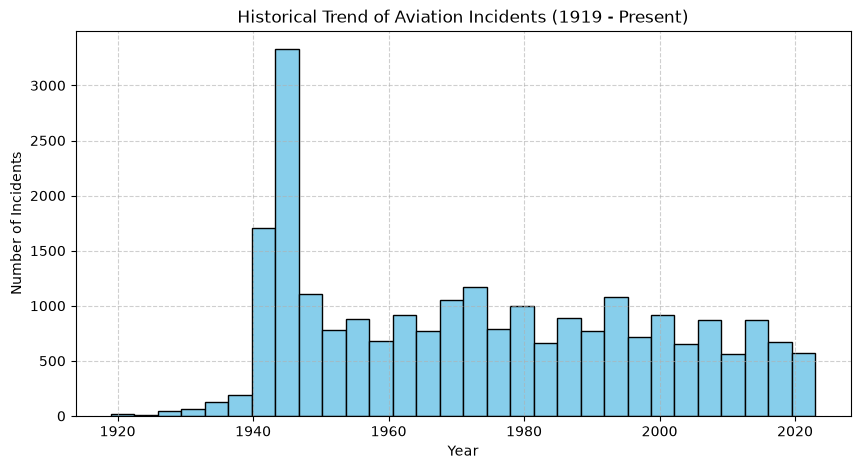

In [9]:
import matplotlib.pyplot as plt

# Clean numeric columns
df["year_clean"] = pd.to_numeric(df["year"], errors="coerce")
df["fatalities_num"] = df["fatalities"].str.extract(r"(\d+)").astype(float)

# Render trend histogram
plt.figure(figsize=(10, 5))
df["year_clean"].dropna().hist(bins=30, color="skyblue", edgecolor="black")
plt.title("Historical Trend of Aviation Incidents (1919 - Present)")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

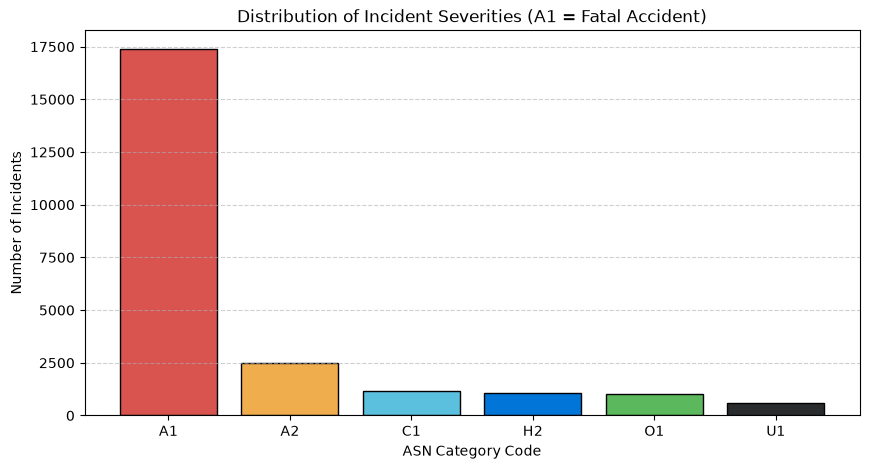

In [10]:
import matplotlib.pyplot as plt

# Count top 6 incident categories
cat_counts = df["cat"].value_counts().head(6)

plt.figure(figsize=(10, 5))
plt.bar(
    cat_counts.index,
    cat_counts.values,
    color=[
        "#d9534f",
        "#f0ad4e",
        "#5bc0de",
        "#0275d8",
        "#5cb85c",
        "#292b2c",
    ],
    edgecolor="black",
)
plt.title("Distribution of Incident Severities (A1 = Fatal Accident)")
plt.xlabel("ASN Category Code")
plt.ylabel("Number of Incidents")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

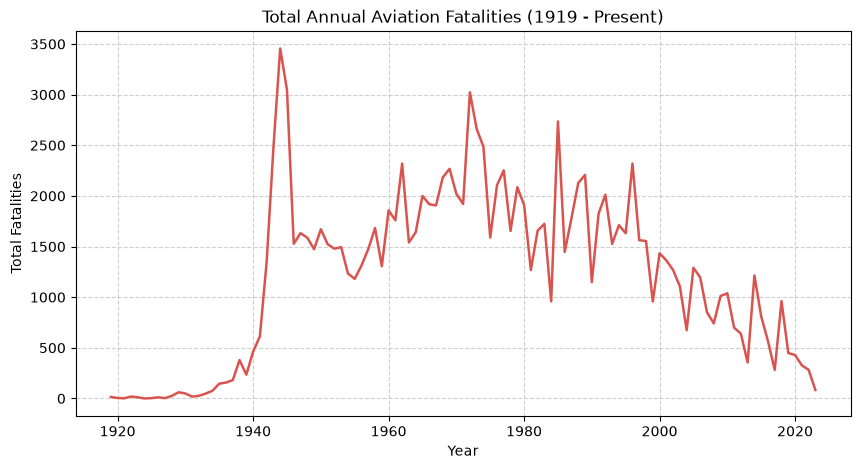

In [11]:
import matplotlib.pyplot as plt

# Group fatalities by year
annual_fatalities = (
    df.groupby("year_clean")["fatalities_num"].sum().reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(
    annual_fatalities["year_clean"],
    annual_fatalities["fatalities_num"],
    color="#d9534f",
    linewidth=1.8,
)
plt.title("Total Annual Aviation Fatalities (1919 - Present)")
plt.xlabel("Year")
plt.ylabel("Total Fatalities")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

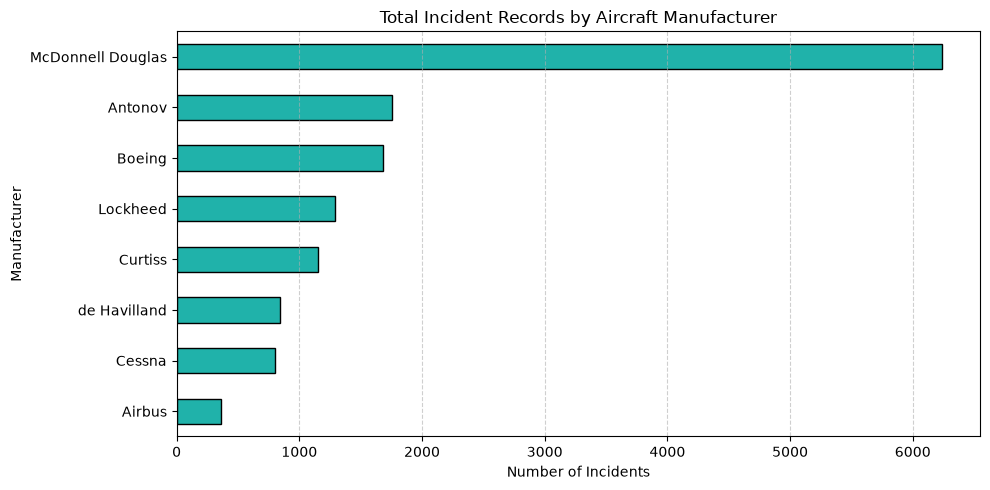

In [12]:
import matplotlib.pyplot as plt

# Classify manufacturers
def classify_mfg(t):
    t = str(t).upper()
    if "BOEING" in t:
        return "Boeing"
    elif "AIRBUS" in t:
        return "Airbus"
    elif "DOUGLAS" in t or "DC-" in t or "MD-" in t:
        return "McDonnell Douglas"
    elif "LOCKHEED" in t:
        return "Lockheed"
    elif "ANTONOV" in t or "AN-" in t:
        return "Antonov"
    elif "CURTISS" in t:
        return "Curtiss"
    elif "DE HAVILLAND" in t or "DHC-" in t:
        return "de Havilland"
    elif "CESSNA" in t:
        return "Cessna"
    else:
        return "Other"


df["manufacturer"] = df["type"].apply(classify_mfg)
mfg_counts = (
    df[df["manufacturer"] != "Other"]["manufacturer"].value_counts().head(8)
)

plt.figure(figsize=(10, 5))
mfg_counts.plot(kind="barh", color="#20B2AA", edgecolor="black").invert_yaxis()
plt.title("Total Incident Records by Aircraft Manufacturer")
plt.xlabel("Number of Incidents")
plt.ylabel("Manufacturer")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

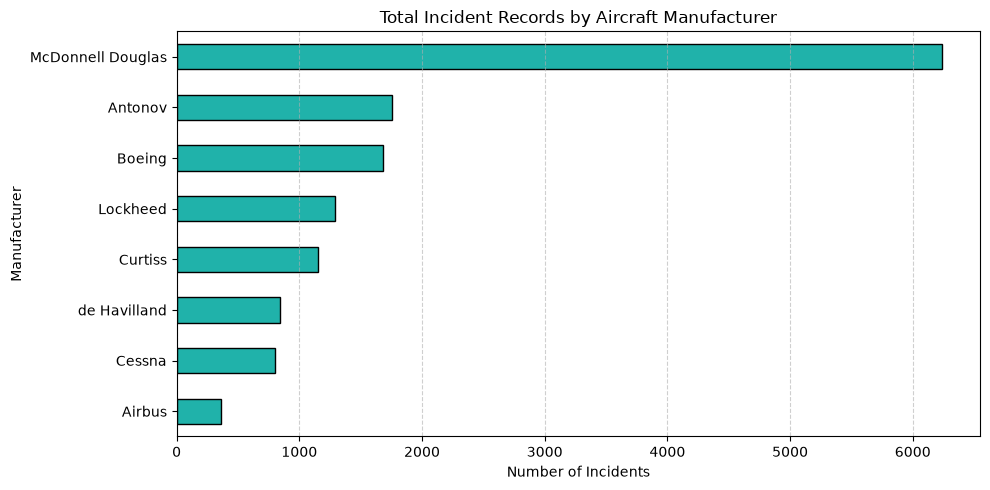

In [13]:
import matplotlib.pyplot as plt

# Classify manufacturers
def classify_mfg(t):
    t = str(t).upper()
    if "BOEING" in t:
        return "Boeing"
    elif "AIRBUS" in t:
        return "Airbus"
    elif "DOUGLAS" in t or "DC-" in t or "MD-" in t:
        return "McDonnell Douglas"
    elif "LOCKHEED" in t:
        return "Lockheed"
    elif "ANTONOV" in t or "AN-" in t:
        return "Antonov"
    elif "CURTISS" in t:
        return "Curtiss"
    elif "DE HAVILLAND" in t or "DHC-" in t:
        return "de Havilland"
    elif "CESSNA" in t:
        return "Cessna"
    else:
        return "Other"


df["manufacturer"] = df["type"].apply(classify_mfg)
mfg_counts = (
    df[df["manufacturer"] != "Other"]["manufacturer"].value_counts().head(8)
)

plt.figure(figsize=(10, 5))
mfg_counts.plot(kind="barh", color="#20B2AA", edgecolor="black").invert_yaxis()
plt.title("Total Incident Records by Aircraft Manufacturer")
plt.xlabel("Number of Incidents")
plt.ylabel("Manufacturer")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

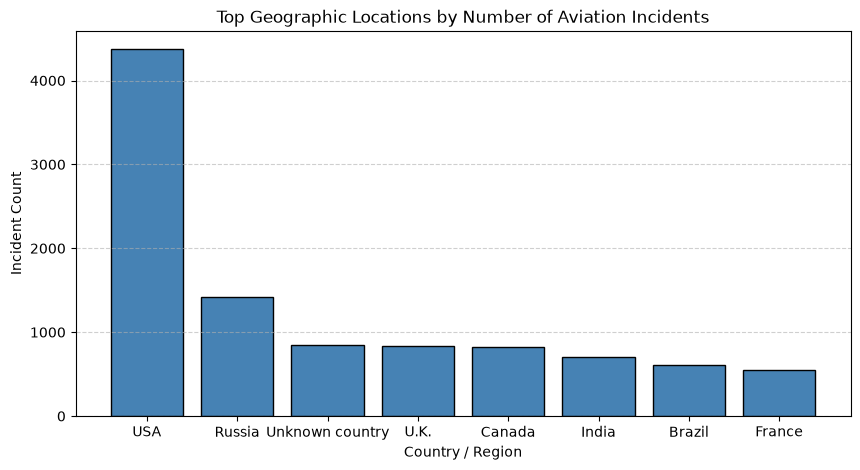

In [14]:
import matplotlib.pyplot as plt

# Get top 8 countries by incident count
top_countries = df["country"].value_counts().head(8).reset_index()
top_countries.columns = ["Country", "Incident Count"]

plt.figure(figsize=(10, 5))
plt.bar(
    top_countries["Country"],
    top_countries["Incident Count"],
    color="#4682B4",
    edgecolor="black",
)
plt.title("Top Geographic Locations by Number of Aviation Incidents")
plt.xlabel("Country / Region")
plt.ylabel("Incident Count")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()

Story Pitch:
Why Commercial Airlines Are Safer Than Ever While Private Flight Lags Behind

While 72% of historical aviation accidents were fatal (A1), modern data reveals a stark divide: major airlines have virtually eliminated fatal risk, logging only minor incidents (A2/C1). Instead, modern hazards have shifted to private aviation.

This piece explores how commercial scale engineered safety—and what it means for flight’s future.